In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Parameters

In [2]:
g = 9.8
k = 0.1  #air resistance cofficent

v0 = 10
theta = np.radians(45)

vx = v0 * np.cos(theta)
vy = v0 * np.sin(theta)

dt = 0.01

## simulation

In [3]:
#withoug the air resstance 
x1,y1 = [0],[0]

while y1[-1] >= 0:
    v = np.sqrt(vx**2 + vy**2)

    ax = 0
    ay = -g

    vx += ax * dt
    vy += ay * dt

    x1.append(x1[-1] + vx*dt)
    y1.append(y1[-1] + vy*dt)

    

In [4]:
#making the velocity reset 
vx = v0 * np.cos(theta)
vy = v0 * np.sin(theta)

#with air resistance
x2,y2 = [0],[0]

while y2[-1] >= 0:
    v = np.sqrt(vx**2 + vy**2)

    ax =  -k * v * vx
    ay =  -g - k*v*vy
    
    vx += ax * dt
    vy += ay * dt
    
    x2.append(x2[-1] + vx*dt)
    y2.append(y2[-1] + vy*dt)




## Plot

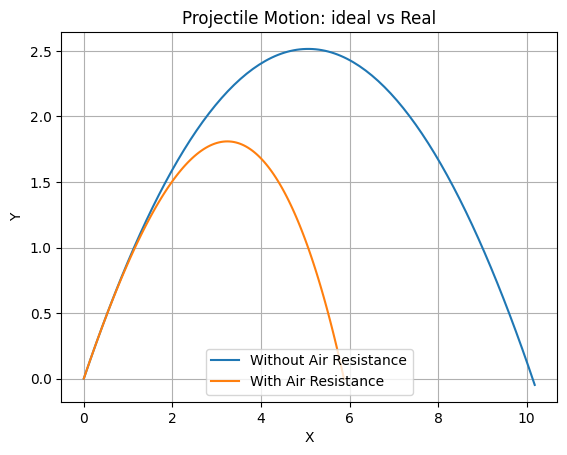

In [5]:
plt.plot(x1,y1,label="Without Air Resistance")
plt.plot(x2,y2,label="With Air Resistance")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Projectile Motion: ideal vs Real")
plt.legend()
plt.grid()
plt.show()

## Comparing diffrent range 

In [66]:
#making a rnage computing function

#With the air drag
def get_range(v0=30,theta=45,k=0.5,dt=0.005):
    g = 9.8
    theta_t = np.radians(theta)

    vx = v0 * np.cos(theta_t)
    vy = v0 * np.sin(theta_t)

    x,y = 0,0

    while y >= 0:
        v = np.sqrt(vx**2 + vy**2)

        ax = -k*v*vx
        ay = -g-k*v*vy

        vx +=ax * dt
        vy +=ay * dt

        x += vx * dt
        y += vy * dt

    return x    


In [67]:
#making a rnage computing function withoug the drag 
def get_range_wt(v0,k=0.5,dt=0.005):
    g = 9.8
    theta=np.radians(45)

    vx = v0 * np.cos(theta)
    vy = v0 * np.sin(theta)

    x,y = 0,0

    while y >= 0:
        v = np.sqrt(vx**2 + vy**2)

        ax = 0
        ay = -g

        vx +=ax * dt
        vy +=ay * dt

        x += vx * dt
        y += vy * dt

    return x    


In [68]:
v_values = [5,10,15,20,25,30]
ranges = []
ranges_2 = []
for v in v_values:
    r = get_range(v)
    r2 = get_range_wt(v)
    ranges.append(r)
    ranges_2.append(r2)
    print(f"v0={v}, range={r:.2f}, range_2={r2:.2f}")


v0=5, range=1.35, range_2=2.55
v0=10, range=2.53, range_2=10.18
v0=15, range=3.23, range_2=22.91
v0=20, range=3.71, range_2=40.80
v0=25, range=4.06, range_2=63.73
v0=30, range=4.34, range_2=91.75


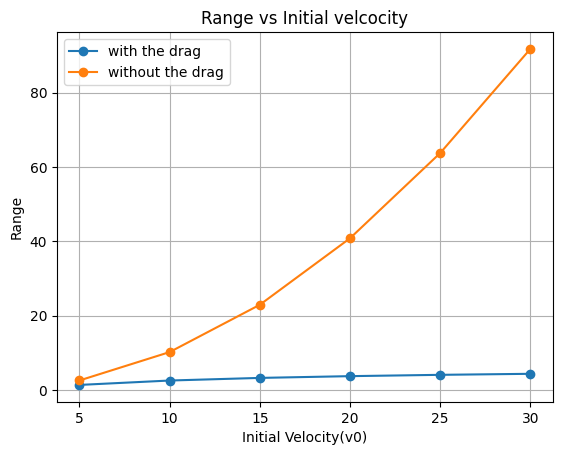

In [69]:
plt.plot(v_values,ranges,marker = 'o',label="with the drag")
plt.plot(v_values, ranges_2,marker = 'o',label="without the drag")
plt.xlabel("Initial Velocity(v0)")
plt.ylabel("Range")
plt.title("Range vs Initial velcocity")

plt.grid()
plt.legend()
plt.show()

## Finding the optimal angel for maximum distance

In [77]:
#Find the angle for maximum range 

theta_values = np.linspace(5,100,300)
ranges = []


for v in theta_values:
    
    r= get_range(20,v)
    ranges.append(r)

    print(f"theta={v:.2f}, range={r:.2f}")

theta=5.00, range=2.40
theta=5.32, range=2.45
theta=5.64, range=2.53
theta=5.95, range=2.58
theta=6.27, range=2.63
theta=6.59, range=2.70
theta=6.91, range=2.75
theta=7.22, range=2.79
theta=7.54, range=2.84
theta=7.86, range=2.90
theta=8.18, range=2.94
theta=8.49, range=2.98
theta=8.81, range=3.02
theta=9.13, range=3.06
theta=9.45, range=3.10
theta=9.77, range=3.13
theta=10.08, range=3.17
theta=10.40, range=3.20
theta=10.72, range=3.24
theta=11.04, range=3.27
theta=11.35, range=3.28
theta=11.67, range=3.31
theta=11.99, range=3.34
theta=12.31, range=3.37
theta=12.63, range=3.40
theta=12.94, range=3.43
theta=13.26, range=3.44
theta=13.58, range=3.47
theta=13.90, range=3.50
theta=14.21, range=3.52
theta=14.53, range=3.54
theta=14.85, range=3.56
theta=15.17, range=3.59
theta=15.48, range=3.60
theta=15.80, range=3.62
theta=16.12, range=3.64
theta=16.44, range=3.65
theta=16.76, range=3.67
theta=17.07, range=3.68
theta=17.39, range=3.70
theta=17.71, range=3.72
theta=18.03, range=3.73
theta=18

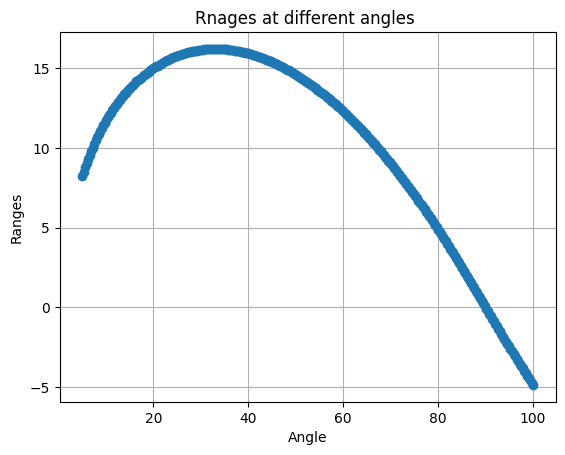

In [89]:
##plot between angles vs ranges. 
plt.plot(theta_values,ranges,marker='o')
plt.xlabel("Angle")
plt.ylabel("Ranges")
plt.title("Rnages at different angles ")

plt.grid()

plt.show()

In [79]:
#find the angle for maximum range
best_index = np.argmax(ranges)  #find the index of  maximum value
best_angle = theta_values[best_index]  #find the angle for maximum range
best_range = ranges[best_index] #value of max range

print(f"Best angle = {best_angle:.2f}, Range= {best_range:.2f} meter")


Best angle = 30.10, Range= 3.99 meter


## find optimal angle for maximum range for differnt drag coefficient(K)

In [80]:
# Changes in range R with changing drag coefficient(k)
k_values = np.linspace(0.0,0.10,10)
Range=[]
for k in k_values:
    r = get_range(30,45,k)
    Range.append(r)
    print(f"drag = {k:.2f}, Range = {r:.2f}")

drag = 0.00, Range = 91.75
drag = 0.01, Range = 53.54
drag = 0.02, Range = 39.31
drag = 0.03, Range = 31.55
drag = 0.04, Range = 26.55
drag = 0.06, Range = 23.04
drag = 0.07, Range = 20.43
drag = 0.08, Range = 18.39
drag = 0.09, Range = 16.76
drag = 0.10, Range = 15.41


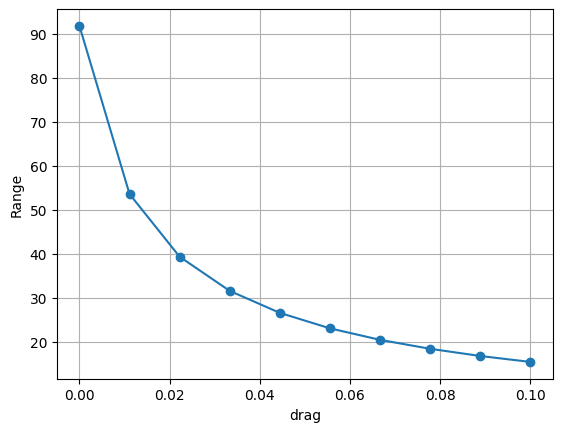

In [91]:
#the plot between Ranges vs k(dragg coefficient) 
plt.plot(k_values,Range,marker='o')
plt.xlabel("drag")
plt.ylabel("Range")

plt.grid()
plt.show()

In [88]:
#find the list of optimal angles for each k 
#optimal angles with maximum rnage associated with them 
optimal_angles = []

for k_t in k_values:
    ranges = []
    for theta_k in theta_values:
        r = get_range(v0=30,theta=theta_k,k=k_t)
        ranges.append(r)

    
    max_value_id = np.argmax(ranges)
    op_angle = theta_values[max_value_id]
    max_range = ranges[max_value_id]
    optimal_angles.append(op_angle)
    print(f"drag = {k_t:.2f}, optima_angle = {op_angle:.2f}, max_range = {max_range:.2f}")
        

drag = 0.00, optima_angle = 45.35, max_range = 91.82
drag = 0.01, optima_angle = 40.90, max_range = 54.00
drag = 0.02, optima_angle = 38.36, max_range = 40.00
drag = 0.03, optima_angle = 37.41, max_range = 32.34
drag = 0.04, optima_angle = 35.82, max_range = 27.40
drag = 0.06, optima_angle = 35.50, max_range = 23.91
drag = 0.07, optima_angle = 34.55, max_range = 21.29
drag = 0.08, optima_angle = 33.60, max_range = 19.25
drag = 0.09, optima_angle = 33.91, max_range = 17.60
drag = 0.10, optima_angle = 33.28, max_range = 16.23


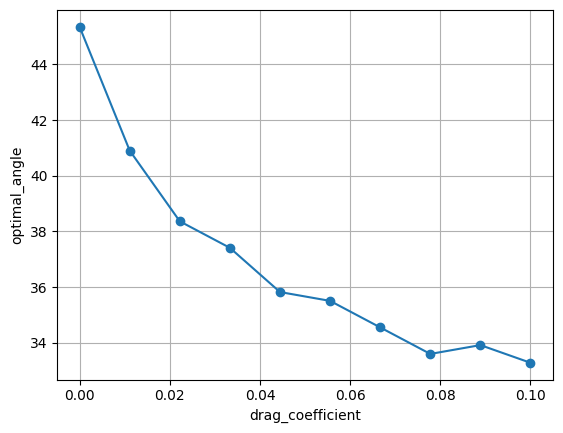

In [90]:
plt.plot(k_values,optimal_angles,marker ='o')
plt.xlabel("drag_coefficient")
plt.ylabel("optimal_angle")

plt.grid()
plt.show()

#small bumbs on grpah are numerical issue